<a href="https://colab.research.google.com/github/Richaweb/DS/blob/main/Netflix_Dataset_Oseon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the dataset
df = pd.read_csv('/content/Netflix Life Impact Dataset (NLID).csv')

In [ ]:
df.head()

,Movie Title,Genre,Release Year,Average Rating,Number of Reviews,Review Highlights,Minute of Life-Changing Insight,How Discovered,Meaningful Advice Taken,Suggested to Friends/Family (Y/N %)
0,The Pursuit of Happyness,Drama,2006,9.1,42000,"""Will Smith’s struggle hit hard. A must-watch!...",78:15 – Chris gets the job,Friend suggested,Persistence pays off.,92% Y
1,The Social Dilemma,Documentary,2020,8.2,35000,"""Eye-opening about tech addiction."" / ""Some cl...",12:40 – Algorithm manipulation,Social media,Limit screen time for mental health.,88% Y
2,Parasite,Thriller/Drama,2019,9.3,50000,"""Masterpiece on class inequality."" / ""Too dark...",1:12:00 – The flood scene,Netflix recommendation,Privilege isn’t always visible.,85% Y
3,Paddington 2,Comedy/Family,2017,8.8,28000,"""Pure joy! Teaches kindness effortlessly."" / ""...",33:10 – Paddington’s jail speech,Friend suggested,Always choose kindness.,95% Y
4,Inception,Sci-Fi,2010,9.0,45000,"""Mind-bending brilliance."" / ""Confusing plot.""",1:05:22 – Cobb’s totem scene,Social media,Reality is subjective.,80% Y


In [ ]:
#basic information about the datasset.
print(df.shape) #identifying rows and columns

(82, 10)


In [ ]:
print(df.dtypes)#identifying datatypes

Movie Title                             object
Genre                                   object
Release Year                             int64
Average Rating                         float64
Number of Reviews                        int64
Review Highlights                       object
Minute of Life-Changing Insight         object
How Discovered                          object
Meaningful Advice Taken                 object
Suggested to Friends/Family (Y/N %)     object
dtype: object


In [ ]:
#missing values
df.isnull().sum() #give me sum of missing values

,0
Movie Title,0
Genre,0
Release Year,0
Average Rating,0
Number of Reviews,0
Review Highlights,0
Minute of Life-Changing Insight,0
How Discovered,0
Meaningful Advice Taken,0
Suggested to Friends/Family (Y/N %),0


On the basis of above result,

In [ ]:
print('statistical summary:\n',df.describe())#calculating a mean, median and mode.

statistical summary:
        Release Year  Average Rating  Number of Reviews
count     82.000000       82.000000          82.000000
mean    2018.304878        7.547561       23146.341463
std        2.365853        1.097160       12796.722141
min     2006.000000        4.000000        8000.000000
25%     2017.250000        6.925000       13000.000000
50%     2019.000000        7.800000       19000.000000
75%     2020.000000        8.300000       31000.000000
max     2021.000000        9.400000       65000.000000


We observed that:

1. This dataset has movies captured from the release year of 2006 to 2021.
2. On an average the maximun munber of movies were release in the year 2018.
3. The on an average for each movie we have obsessed was 7.5 which was falling between the 4.0 to 9.4 as the maximum rating.
4. The overall average reviews per movie was recorded as 23146,where the maximum reviews were 13000 and maximum were observed were 65000.

#Cleaning and Renaming

In [ ]:
df.dropna(how = 'all', inplace = True)#dropping the missing value.


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')#dropping the spaces and converting into the lower case.

In [ ]:
df.head()

,movie_title,genre,release_year,average_rating,number_of_reviews,review_highlights,minute_of_life-changing_insight,how_discovered,meaningful_advice_taken,suggested_to_friends/family_(y/n_%)
0,The Pursuit of Happyness,Drama,2006,9.1,42000,"""Will Smith’s struggle hit hard. A must-watch!...",78:15 – Chris gets the job,Friend suggested,Persistence pays off.,92% Y
1,The Social Dilemma,Documentary,2020,8.2,35000,"""Eye-opening about tech addiction."" / ""Some cl...",12:40 – Algorithm manipulation,Social media,Limit screen time for mental health.,88% Y
2,Parasite,Thriller/Drama,2019,9.3,50000,"""Masterpiece on class inequality."" / ""Too dark...",1:12:00 – The flood scene,Netflix recommendation,Privilege isn’t always visible.,85% Y
3,Paddington 2,Comedy/Family,2017,8.8,28000,"""Pure joy! Teaches kindness effortlessly."" / ""...",33:10 – Paddington’s jail speech,Friend suggested,Always choose kindness.,95% Y
4,Inception,Sci-Fi,2010,9.0,45000,"""Mind-bending brilliance."" / ""Confusing plot.""",1:05:22 – Cobb’s totem scene,Social media,Reality is subjective.,80% Y


Three types of EDA -

Exploartory data Analysis:-

1.Univariate Analysis (individual, columns)

2.Bivariate Analysis (two columns)

3.Multivariate columns(Multiple columns)

- Numerical
- Categorical
- Numerical -numerical
- Categorical-categorical
- Numerical - categorical

In [ ]:
#apply theme
sns.set_style('whitegrid')
sns.set_palette('Reds')
sns.set_context('notebook', font_scale=1.2)

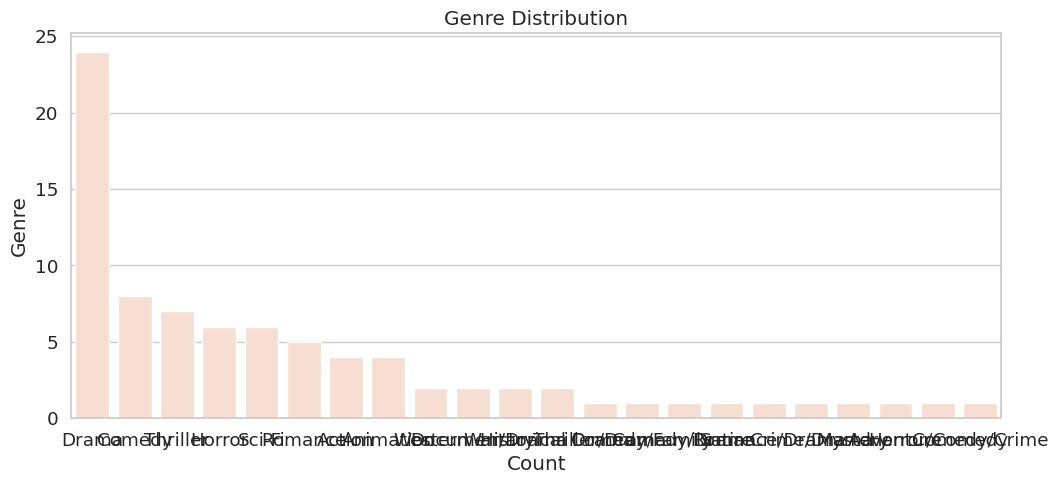

In [ ]:
#Genre distribution
plt.figure(figsize=(12,5))
sns.countplot(x = 'genre', data = df , order = df['genre'].value_counts().index)
plt.title('Genre Distribution')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

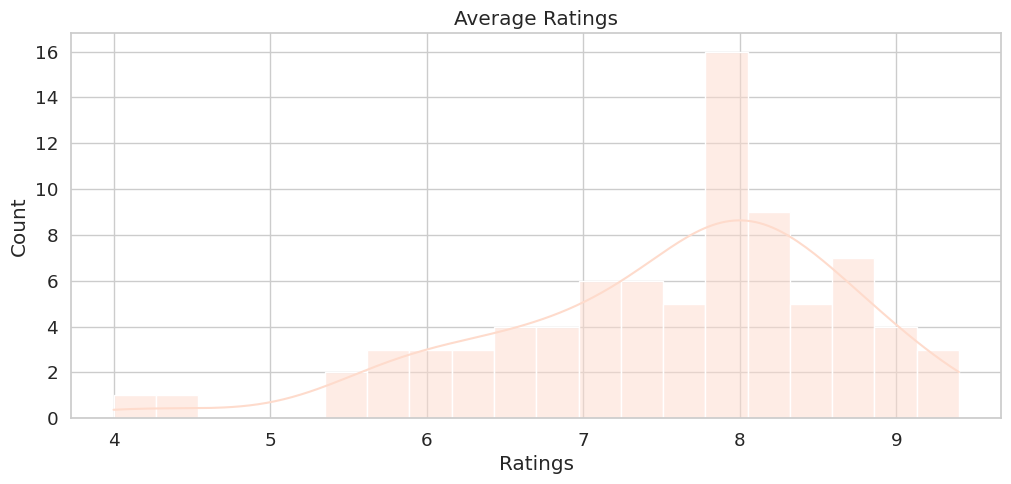

In [ ]:
#Average rating

plt.figure(figsize=(12,5))
sns.histplot(df['average_rating'],kde= True, bins =20)
plt.title('Average Ratings')
plt.xlabel('Ratings')
plt.show()


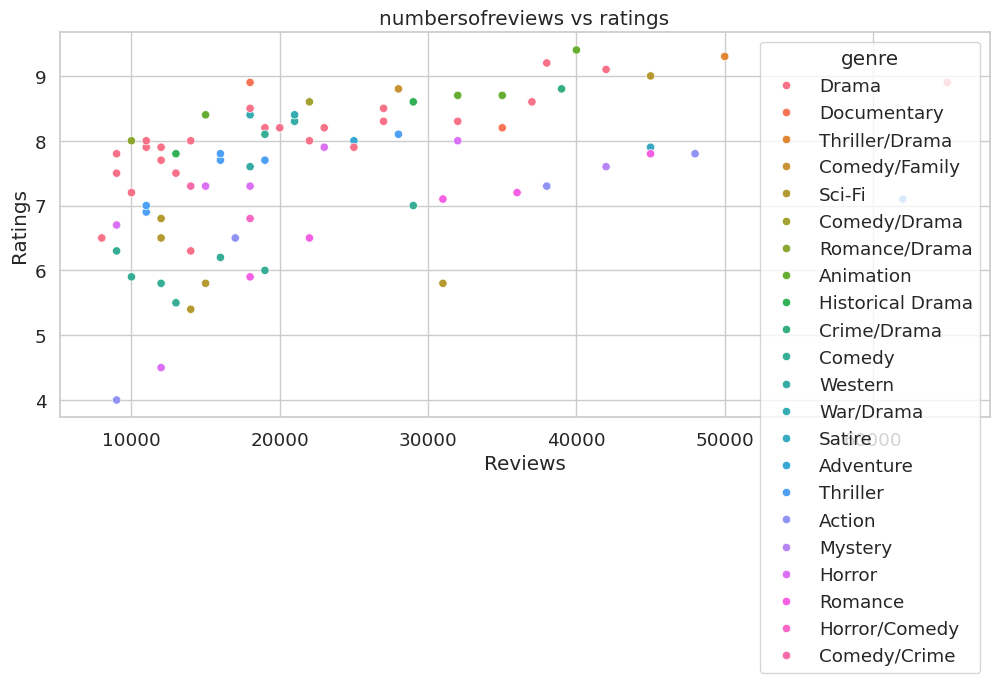

In [ ]:
#Ratings vs Reviews
plt.figure(figsize=(12,5))
sns.scatterplot(x = 'number_of_reviews', y = 'average_rating', data = df, hue = 'genre')
plt.title('numbersofreviews vs ratings')
plt.xlabel('Reviews')
plt.ylabel('Ratings')
plt.show()

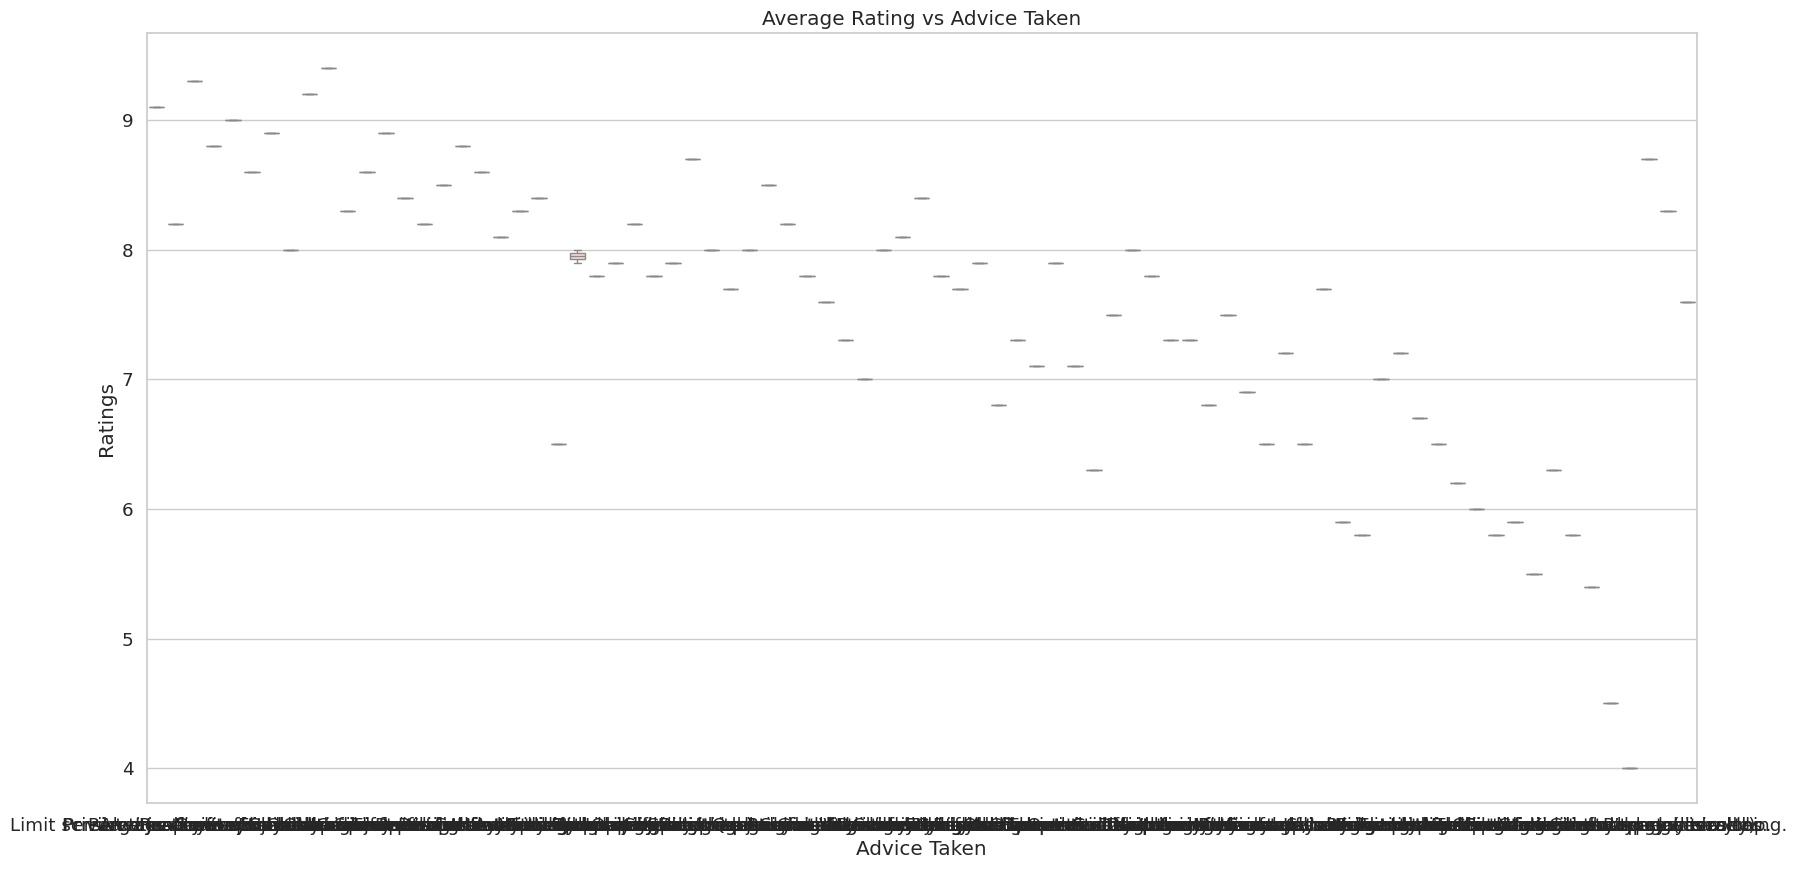

In [ ]:
#average rating vs advice taken

plt.figure(figsize=(20,10))
sns.boxplot(data = df, x = 'meaningful_advice_taken', y = 'average_rating')
plt.title('Average Rating vs Advice Taken')
plt.xlabel('Advice Taken')
plt.ylabel('Ratings')
plt.show()

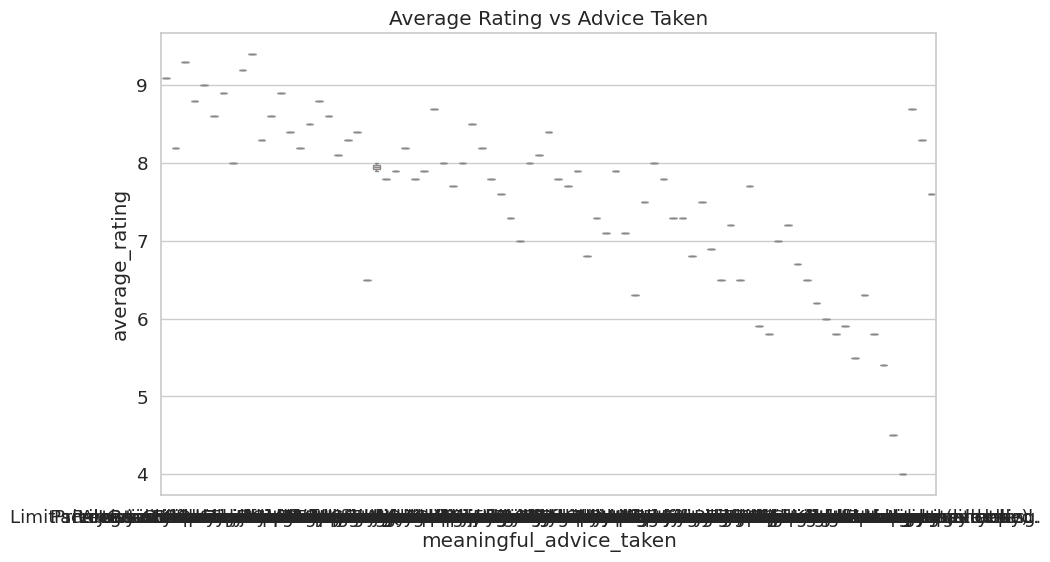

In [ ]:
top_3 = df['meaningful_advice_taken'].value_counts().nlargest(3).index
filter_top = df[df['meaningful_advice_taken'].isin(top_3)]


plt.figure(figsize=(10,6))
sns.boxplot(data = df, x = 'meaningful_advice_taken', y = 'average_rating')
plt.title('Average Rating vs Advice Taken')
plt.show()

#Transformation

In [ ]:
#extracting first review from review highlights
df['review_highlights'] = df['review_highlights'].str.split(',').str[0].str.strip()
df.head()

,movie_title,genre,release_year,average_rating,number_of_reviews,review_highlights,minute_of_life-changing_insight,how_discovered,meaningful_advice_taken,suggested_to_friends/family_(y/n_%)
0,The Pursuit of Happyness,Drama,2006,9.1,42000,"""Will Smith’s struggle hit hard. A must-watch!...",78:15 – Chris gets the job,Friend suggested,Persistence pays off.,92% Y
1,The Social Dilemma,Documentary,2020,8.2,35000,"""Eye-opening about tech addiction."" / ""Some cl...",12:40 – Algorithm manipulation,Social media,Limit screen time for mental health.,88% Y
2,Parasite,Thriller/Drama,2019,9.3,50000,"""Masterpiece on class inequality."" / ""Too dark...",1:12:00 – The flood scene,Netflix recommendation,Privilege isn’t always visible.,85% Y
3,Paddington 2,Comedy/Family,2017,8.8,28000,"""Pure joy! Teaches kindness effortlessly."" / ""...",33:10 – Paddington’s jail speech,Friend suggested,Always choose kindness.,95% Y
4,Inception,Sci-Fi,2010,9.0,45000,"""Mind-bending brilliance."" / ""Confusing plot.""",1:05:22 – Cobb’s totem scene,Social media,Reality is subjective.,80% Y


In [ ]:
#split life changing into two columns

import re

def split_insight(insight):
    match = re.match(r'(\d+):(\d+)\s+[--]\s+(.*)',str(insight))
    if match:
      minutes,seconds, desc = int(match.group(1)), int(match.group(2)), match.group(3)
      total_seconds = minutes * 60 + seconds
      return pd.Series(total_seconds, desc)
    else:
      return pd.Series([np.nan, None])

df[['insight_sec','insight_desc']] = df['minute_of_life-changing_insight'].apply(split_insight)

In [ ]:
df.head()

,movie_title,genre,release_year,average_rating,number_of_reviews,review_highlights,minute_of_life-changing_insight,how_discovered,meaningful_advice_taken,suggested_to_friends/family_(y/n_%),insight_sec,insight_desc
0,The Pursuit of Happyness,Drama,2006,9.1,42000,"""Will Smith’s struggle hit hard. A must-watch!...",78:15 – Chris gets the job,Friend suggested,Persistence pays off.,92% Y,NaN,NaN
1,The Social Dilemma,Documentary,2020,8.2,35000,"""Eye-opening about tech addiction."" / ""Some cl...",12:40 – Algorithm manipulation,Social media,Limit screen time for mental health.,88% Y,NaN,NaN
2,Parasite,Thriller/Drama,2019,9.3,50000,"""Masterpiece on class inequality."" / ""Too dark...",1:12:00 – The flood scene,Netflix recommendation,Privilege isn’t always visible.,85% Y,NaN,NaN
3,Paddington 2,Comedy/Family,2017,8.8,28000,"""Pure joy! Teaches kindness effortlessly."" / ""...",33:10 – Paddington’s jail speech,Friend suggested,Always choose kindness.,95% Y,NaN,NaN
4,Inception,Sci-Fi,2010,9.0,45000,"""Mind-bending brilliance."" / ""Confusing plot.""",1:05:22 – Cobb’s totem scene,Social media,Reality is subjective.,80% Y,NaN,NaN


In [ ]:
#Split suggested to friends and family

df[['suggest(%)','suggest_flag']] = df['suggested_to_friends/family_(y/n_%)']\
.str.extract(r'(\d+)%\s*(YN])')

df['suggest(%)']= df['suggest(%)'].astype(float)
df['suggest_flag']= df['suggest_flag'].map({'Y':True,'N':False})

df['suggest_level'] = pd.cut(df['suggest(%)'],bins = [0,75,85,100], labels = ['low','medium','high'])

In [ ]:
df.head()

,movie_title,genre,release_year,average_rating,number_of_reviews,review_highlights,minute_of_life-changing_insight,how_discovered,meaningful_advice_taken,suggested_to_friends/family_(y/n_%),insight_sec,insight_desc,suggest(%),suggest_flag,suggest_level
0,The Pursuit of Happyness,Drama,2006,9.1,42000,"""Will Smith’s struggle hit hard. A must-watch!...",78:15 – Chris gets the job,Friend suggested,Persistence pays off.,92% Y,NaN,NaN,NaN,NaN,NaN
1,The Social Dilemma,Documentary,2020,8.2,35000,"""Eye-opening about tech addiction."" / ""Some cl...",12:40 – Algorithm manipulation,Social media,Limit screen time for mental health.,88% Y,NaN,NaN,NaN,NaN,NaN
2,Parasite,Thriller/Drama,2019,9.3,50000,"""Masterpiece on class inequality."" / ""Too dark...",1:12:00 – The flood scene,Netflix recommendation,Privilege isn’t always visible.,85% Y,NaN,NaN,NaN,NaN,NaN
3,Paddington 2,Comedy/Family,2017,8.8,28000,"""Pure joy! Teaches kindness effortlessly."" / ""...",33:10 – Paddington’s jail speech,Friend suggested,Always choose kindness.,95% Y,NaN,NaN,NaN,NaN,NaN
4,Inception,Sci-Fi,2010,9.0,45000,"""Mind-bending brilliance."" / ""Confusing plot.""",1:05:22 – Cobb’s totem scene,Social media,Reality is subjective.,80% Y,NaN,NaN,NaN,NaN,NaN


#Statistics-

1.Descriptive(trends, pattern, distribution skewness)

2.Inferential (hypothesis test,(null and alternate hypothesis)T- test,Anova, chi- square)

Data type:
 - categorical(qualitative)bar, count, scatter, piechart
  -Nominal
  -Ordinal

- Numerical (Qualitative)
 -discreet - whole number - line ,scatter, heatmap, pie
 -continuous -range,hieght,age - histogram

#Descriptive

1. measure of central tendency(mean, median, mode)
2. measure of variance (variance, std deviation)
3. measure of frequency(range, frequency)
4. skewness
5. kurtosis

In [ ]:
num_col =df.select_dtypes(include=np.number)


In [ ]:
desc_stats =pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'std': df.std(numeric_only=True),
    'variance': df.var(numeric_only=True),
    'skewness':df.skew(numeric_only=True),
    'kurtosis':df.kurtosis(numeric_only=True)
})

In [ ]:
desc_stats

,Mean,Median,std,variance,skewness,kurtosis
release_year,2018.304878,2019.0,2.365853,5.597260e+00,-2.478822,9.829926
average_rating,7.547561,7.8,1.097160,1.203759e+00,-0.840577,0.644843
number_of_reviews,23146.341463,19000.0,12796.722141,1.637561e+08,1.137015,0.936889
insight_sec,NaN,NaN,NaN,NaN,NaN,NaN
insight_desc,NaN,NaN,NaN,NaN,NaN,NaN
Post2015,0.939024,1.0,0.240758,5.796447e-02,-3.738192,12.272905
suggest(%),NaN,NaN,NaN,NaN,NaN,NaN


Hypothesis test

Measure to check the condition on the basis of two different scenarios.

1.Null hypothesis(HO):there is no significant relationship or effect between the samples.

2.Alternate hypothesis(H1/Ha): there is a significant relationship or effect betweeb the samples.


Ttest(two samples)

 -One sample(mean between population and sample)
 -dependent two samples(mean value of two sample combined)
 - independent two sample(mean valueof two independent sample)

ANOVA(analysis of variance) three or more  than three samples.

- compare the mean ratio between the three or morethan three samples.


chi- square(categorical)
-relationship between the categorical samples.




significance value(alpha):measurement of correctness

-0.05
-0.01

pvalue : probability
-p>0.05:
-p<0.05:

T-tests

Ho = there is no differences in the average ratings of movie before and after2015.

H1 = there is differences in the average ratings of movie before and after2015.

In [ ]:
from scipy import stats

df['Post2015']= df['release_year'] > 2015
before_2015 = df[df['Post2015']== False]['average_rating']
after_2015 = df[df['Post2015']== True]['average_rating']

In [ ]:
t_stat,p_value = stats.ttest_ind(before_2015,after_2015)
print('t-statistic:',t_stat)
print('p-value:',p_value)

t-statistic: 2.7376763180007413
p-value: 0.007622947723985303


H0 = The mean ratings are same across all genre.

H1 = At least one genre has different mean ratings.

In [ ]:
from os import name
groups = [group['average_rating'].dropna() for name, group in df.groupby('genre') if len(group)>1]

anova_results =stats.f_oneway(*groups)


In [ ]:
print('f-statistic:',anova_results.statistic)
print('p-value:',anova_results.pvalue)

f-statistic: 5.043083038707258
p-value: 1.6077354246351215e-05


#Machine Learning - Introduction

There are 6 types of regression model.
- simple linear regression
- polynomial regression
- multiple  regression
- support vector regressor
- decision tree regressor
- random forest regressor

1.Simple linear regression - are those one dependent and one independent variables . these kind of relationship is known as simple linear regression.

y = mx+c

y = target variable.

x = independent variables.

c = residual value.

2.Multiple linear regressor - the relationship between multiple independent variables and one dependent variables.

y = mx1+mx2+mx3+...+mxn+c

3.Ploynominal regression - multiple independent variable are involve, the relatinship is not straight.They dont have staright relationship. It will curve,sigmoid, parabolla.

4.Supprt Vector regressor - we deal with two or more than two categories of data where we try to create a perfect line and adjust them within a specific range.

5. Decision Tree regression - are those algorithm in which we create a hierarchical structure to understand the dependency of the data on each other. It is might also lead to bias results. We sholud avoid the bias reslts. until and unless value of mean and stad divation becomes 0. It is tree method.

eg. house price.

6. Random forest regression - combine the decision trees to enhance the prediction accuracy. it is also called esemble method.


#Classification Model

- support vector classifier
- random forest classifier
- decision trees
- logistic regression
- knn
- Naive bayes

1. Logistc regression - get the output in binary format or multiclass format. it means you get the data into categorical format. if its two catgeories its binary format and if its more than two categories its multiclass formate

 calculate the value on log method. it involve log and baselog.independent and dependent variables. it try to predict value in multiple category. the relationship lies between 0 and 1. the threhold value is 0.5.

 for.e.g. - credit score.


2. KNN - nearest neighbour  of the given data point. so any data that is forming nearest connection to the data point are all those group will be consider as knn.
categorical analysis is known as knn analysis.so what happen in Knn analysis - In knn analysis it works on mean value or on centroid values.

 for.eg: images from google drive from that google drive you are looking out 1 image. related images will displayed after checking the images.most related images will be provides by google images.

3. Naives bayes- based on probabilities bayes therom. to predict the weather you should have current status and previous statues  and you should also have some factor which are going to affect the analysis. try to predict wheather its going to rain or not.

4. Support vector classification - segregation of the data is called support vector classifier.



5. Decision trees - based on categorical information it will predict the waether you should accpet job offer or not, travel allowances, wfh or wfo, on the basis of that prediction is made and its called decision trees.

6. Random forest - combine so many decision trees are called random forest classifiers.

#Model Evaluation and Selection:-
#Regression -

1. Mean Absolute Error (MAE)
2. Mean Squared Error(MSE)
3. R-Squared

if the value is very high, its not performing good. if its negative , its a worst model.if its very low your model is perfect. whereas, the value of R-squared near by 1 then you have perfect model and if its near by 0 its worst model.

#Classification -

1. Accuracy - proportion of true results among the total no. of cases examined.
2. Precision - accuarcy of positive predictions
3. Recall - correctly predicted
4. F1 Score- ratio btw precison and recall
5. Roc - AUC curve- repesenting models ability, if the difference is very high that means model is not good.if the difference is low that means model is perfect.


#Unsupervised Learning:-
we work with undefined dataset.deals with unlabeled data set. input is known but output is not known.clear objective is not known in the unsupervised learning method.

1. Clustering - grouping the similar data points, makingit easier to identify pattern and relationships.

2. dimensionality reduction - when dealing with dataset,reduce the number of variables based on the its importance.once the number of variable are reduce its become easy to task to understand what variable are contributing high and what are contributing low.

3. density estimation - size of the dataset.

Application of unsupervised learing

1. customer segmentation.
2. Anomaly detection.
3. data visualization.

#Clustering model-

1. K-means clustering - cluster is formed on basis of their means value.
- partitioning methods.

2. hireraical clustering- we have two different sub group.distribution of hirerichy in the organisation.
- aglomertic
- dandogram

3. Density based methods - a kind of clustering which overlap with each other.
- for eg:flora and fauna


importance of dimensionality reduction:
1. PCA
- image processing
- finance and genomics

2. t- distributed stochastic.- to break down any complex information. we break the dataset in small small segment to understand the information.

#Common library for clustering algorithm:

- scikit learn
- tensorflow


#Reinforcement Learning -

RL is bassically ml technique instead of independent variable dependent variable agents is involve. its psychological and behavioural method. for e.g.: according to the different environment it provide the

#Difference btw supervised unsupervised learning and RL.









#Recommendation system -

using machin learning suggests product sservies or content to users based on the prefernces or behaviour.there are multiple approahes depending on data avaiability and project complexity. here an overview of key concepts,types and sample implementating using Python.

Types of recommendation systems:

1. content based.
2. collaborative filtering.
3. hybrid models.

combines content based and collaborative filtering